# Merge Sort and Quicksort

## Merge Sort

Merge sort is a divide-and-conquer algorithm:

- **Divide** the array into two halves.
- **Conquer** by recursively sorting each half.
- **Combine** the two sorted halves using a `merge` step that runs in $O(n)$ time.

Overall running time: $O(n \log n)$ in all cases.

In [14]:
def merge(left, right):
    """Merge two sorted lists into a single sorted list."""
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    # Append any remaining elements
    result.extend(left[i:])
    result.extend(right[j:])
    return result


def merge_sort(arr):
    """Sort a list using merge sort. Returns a new sorted list."""
    if len(arr) <= 1:
        return arr[:]

    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)


In [15]:
# Quick test
test_array = [38, 27, 43, 3, 9, 82, 10]
print("Original:", test_array)
print("Sorted:  ", merge_sort(test_array))


Original: [38, 27, 43, 3, 9, 82, 10]
Sorted:   [3, 9, 10, 27, 38, 43, 82]


## Randomized Quicksort

Quicksort is also divide-and-conquer, but it does the work *before* the recursive calls (via partitioning) instead of after (via merging):

- **Pick a pivot.**
- **Partition** the array so elements smaller than the pivot come before it and elements larger come after.
- **Recurse** on the two partitions.

In this implementation, `partition(A, p, q)` uses `A[p]` (the first element of the range) as the pivot `x`. `randomized_partition` picks a uniformly random element and swaps it into position `p` first, then calls the same `partition` — this is what makes the pivot choice random and avoids the $O(n^2)$ worst case that a fixed first-element pivot hits on already-sorted or adversarial input.

This implementation sorts **in place**.

In [16]:
import random

def partition(arr, p, q):
    """Partition arr[p..q] using arr[p] as the pivot.
    Rearranges arr[p..q] in place and returns the pivot's final index i,
    such that arr[p..i-1] <= arr[i] and arr[i+1..q] > arr[i]."""
    x = arr[p]      # pivot
    i = p
    for j in range(p + 1, q + 1):
        if arr[j] <= x:
            i = i + 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[p], arr[i] = arr[i], arr[p]
    return i


def randomized_partition(arr, p, q):
    """Choose a random pivot, swap it into position p, then partition normally."""
    rand_index = random.randint(p, q)
    arr[rand_index], arr[p] = arr[p], arr[rand_index]
    return partition(arr, p, q)


def quicksort(arr, p=0, q=None):
    """Sort arr[p..q] in place using randomized quicksort."""
    if q is None:
        q = len(arr) - 1

    if p < q:
        pivot_index = randomized_partition(arr, p, q)
        quicksort(arr, p, pivot_index - 1)
        quicksort(arr, pivot_index + 1, q)

    return arr


In [17]:
# Quick test
test_array = [38, 27, 43, 3, 9, 82, 10]
print("Original:", test_array)
quicksort(test_array)
print("Sorted:  ", test_array)


Original: [38, 27, 43, 3, 9, 82, 10]
Sorted:   [3, 9, 10, 27, 38, 43, 82]


**Note:** unlike `merge_sort` above (which returns a *new* list), `quicksort` sorts *in place* and also returns the array for convenience. Keep this difference in mind — you may need to pass in a **copy** of a list (`arr[:]` or `list(arr)`) if you want to keep the original around.

## Exercises

1. Plot graphs to illustrate that Randomized Quicksort is generally faster than Mergesort, Bubblesort. Justify why this happens.
2. Give inputs in such a way that mergesort is faster than randomized quicksort. Plot the corresponding graph. Justify why this happens.
3. Modify all three algorithms to count the number of comparisons and swaps. Plot the number of comparisons and swaps against input size and compare the results.
4. When will you use the following algorithms?

    (i) Bubblesort alone
   
   (ii) Mergesort alone
   
   (iii) Randomized quicksort alone
   
   (iv) Mergesort first, followed by quicksort
   
   (v) Quicksort first, followed by mergesort


In [18]:
import random
import time
import matplotlib.pyplot as plt

In [19]:
# ---------------- BUBBLE SORT ----------------

def bubble_sort(arr, count):
    n = len(arr)

    for i in range(n - 1):
        for j in range(n - 1 - i):
            count["comparisons"] += 1

            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                count["swaps"] += 1

    return arr

# ---------------- EXERCISE 1 ----------------

sizes = [100, 500, 1000, 2000, 3000, 5000, 10000, 20000]

quick_times = []
merge_times = []
bubble_times = []

for n in sizes:
    data = [random.randint(1, 100000) for _ in range(n)]

    start = time.perf_counter()
    quicksort(data.copy())
    quick_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    merge_sort(data.copy())
    merge_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    bubble_sort(data.copy(), {"comparisons": 0, "swaps": 0})
    bubble_times.append(time.perf_counter() - start)

plt.figure(figsize=(10,6))
plt.plot(sizes, quick_times, marker='o', label="Randomized Quicksort")
plt.plot(sizes, merge_times, marker='o', label="Mergesort")
plt.plot(sizes, bubble_times, marker='o', label="Bubblesort")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Sorting Time Comparison")
plt.legend()
plt.grid()
plt.show()

KeyboardInterrupt: 

#### Justification

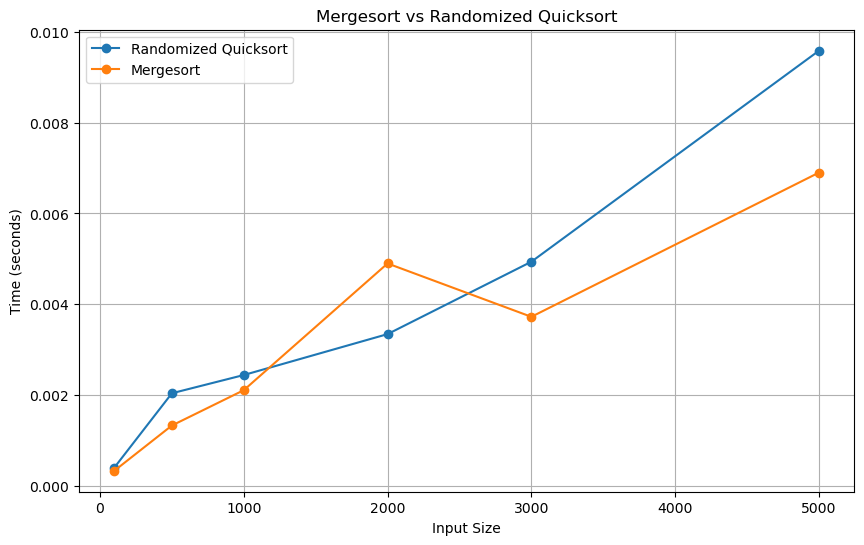

In [22]:
# ---------------- EXERCISE 2 ----------------
sizes2 = [100, 500, 1000, 2000, 3000, 5000]

quick_times2 = []
merge_times2 = []

for n in sizes2:
    data = list(range(n))

    start = time.perf_counter()
    quicksort(data.copy())
    quick_times2.append(time.perf_counter() - start)

    start = time.perf_counter()
    merge_sort(data.copy())
    merge_times2.append(time.perf_counter() - start)

    
plt.figure(figsize=(10,6))
plt.plot(sizes2, quick_times2, marker='o', label="Randomized Quicksort")
plt.plot(sizes2, merge_times2, marker='o', label="Mergesort")
plt.xlabel("Input Size")
plt.ylabel("Time (seconds)")
plt.title("Mergesort vs Randomized Quicksort")
plt.legend()
plt.grid()
plt.show()

#### Justification

In [23]:
# ---------------- EXERCISE 3 ----------------
sizes3 = [10, 50, 100, 200, 500]

quick_comp = []
merge_comp = []
bubble_comp = []

quick_swap = []
merge_swap = []
bubble_swap = []

for n in sizes3:
    data = [random.randint(1, 10000) for _ in range(n)]

    c = {"comparisons": 0, "swaps": 0}
    quicksort(data.copy(), count=c)
    quick_comp.append(c["comparisons"])
    quick_swap.append(c["swaps"])

    c = {"comparisons": 0, "swaps": 0}
    merge_sort(data.copy(), c)
    merge_comp.append(c["comparisons"])
    merge_swap.append(c["swaps"])

    c = {"comparisons": 0, "swaps": 0}
    bubble_sort(data.copy(), c)
    bubble_comp.append(c["comparisons"])
    bubble_swap.append(c["swaps"])


plt.figure(figsize=(10,6))
plt.plot(sizes3, quick_comp, marker='o', label="Quick - Comparisons")
plt.plot(sizes3, merge_comp, marker='o', label="Merge - Comparisons")
plt.plot(sizes3, bubble_comp, marker='o', label="Bubble - Comparisons")
plt.xlabel("Input Size")
plt.ylabel("Number of Comparisons")
plt.title("Comparisons vs Input Size")
plt.legend()
plt.grid()
plt.show()


plt.figure(figsize=(10,6))
plt.plot(sizes3, quick_swap, marker='o', label="Quick - Swaps")
plt.plot(sizes3, merge_swap, marker='o', label="Merge - Swaps")
plt.plot(sizes3, bubble_swap, marker='o', label="Bubble - Swaps")
plt.xlabel("Input Size")
plt.ylabel("Number of Swaps")
plt.title("Swaps vs Input Size")
plt.legend()
plt.grid()
plt.show()

TypeError: quicksort() got an unexpected keyword argument 'count'

#### ---------------- EXERCISE 4 ----------------

| Algorithm | When to Use |
|---|---|
| **Bubblesort** | Very small inputs and simple implementations |
| **Mergesort** | Stable sorting and guaranteed `O(n log n)` performance |
| **Randomized Quicksort** | Fast average-case, in-place sorting |
| **Mergesort → Quicksort** | Specialized hybrid situations |
| **Quicksort → Mergesort** | Specialized hybrid situations |